In [1]:
import os
import sys
from pathlib import Path

# Configure CUDA environment for RTX 3050 with CUDA 13.0
venv_nvidia = Path(sys.prefix) / "lib/python3.13/site-packages/nvidia"

# Build comprehensive LD_LIBRARY_PATH with all CUDA libraries
cuda_lib_paths = [
    '/usr/lib/x86_64-linux-gnu',
    '/usr/lib',
    str(venv_nvidia / 'cuda_runtime/lib'),
    str(venv_nvidia / 'cudnn/lib'),
    str(venv_nvidia / 'cuda_nvcc/lib'),
    str(venv_nvidia / 'cuda_cupti/lib'),
    str(venv_nvidia / 'cufft/lib'),
    str(venv_nvidia / 'cusolver/lib'),
    str(venv_nvidia / 'cusparse/lib'),
    str(venv_nvidia / 'curand/lib'),
    str(venv_nvidia / 'cublas/lib'),
    str(venv_nvidia / 'nccl/lib'),
]

existing_paths = [p for p in cuda_lib_paths if Path(p).exists()]
new_ld_path = ':'.join(existing_paths) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['LD_LIBRARY_PATH'] = new_ld_path
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf                                    # TensorFlow deep learning framework
import matplotlib.pyplot as plt                            # Plotting library
import matplotlib.image as mpimg                           # Image loading and manipulation library
from tensorflow.keras.models import Sequential, Model      # Sequential and Functional API for building models
from tensorflow.keras.optimizers import Adam               # Adam optimizer for model training
from tensorflow.keras.callbacks import EarlyStopping       # Early stopping callback for model training
from tensorflow.keras.regularizers import l1, l2           # L1 and L2 regularization for model regularization
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Data augmentation and preprocessing for images
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, AveragePooling2D, MaxPooling2D, BatchNormalization  
# Various types of layers for building neural networks
from tensorflow.keras.applications import DenseNet121, EfficientNetB4, Xception, VGG16, VGG19   # Pre-trained models for transfer learning

ModuleNotFoundError: No module named 'tensorflow'

## GPU/CUDA Configuration
Verifying GPU setup for RTX 3050 (6GB VRAM) with CUDA 13.0

In [27]:
# GPU and CUDA Setup Verification for RTX 3050
import sys

print("\n" + "=" * 90)
print("🎮 NVIDIA RTX 3050 GPU & CUDA VERIFICATION")
print("=" * 90)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"\n📦 Software Versions:")
print(f"  - TensorFlow: {tf.__version__}")
print(f"  - Keras: {tf.keras.__version__}")
print(f"  - Python: {sys.version.split()[0]}")
print(f"  - CUDA Libraries: Available in venv")

print(f"\n🖥️  Hardware Detection:")
print(f"  - GPUs Available: {len(gpus)}")
print(f"  - CPUs Available: {len(cpus)}")

if gpus:
    print("\n✅ GPU DETECTED AND READY!")
    for i, gpu in enumerate(gpus):
        print(f"   GPU {i}: {gpu}")
    
    # Configure GPU memory
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\n✓ GPU Memory Growth: ENABLED (Dynamic allocation)")
        print("✓ VRAM Management: Active (prevents OOM errors)")
        
        # GPU test
        print("\n🧪 Running GPU Computation Test...")
        with tf.device('/GPU:0'):
            test_a = tf.random.normal((1000, 1000))
            test_b = tf.random.normal((1000, 1000))
            test_result = tf.matmul(test_a, test_b)
        
        print("✅ GPU Computation Test: SUCCESS!")
        print("\n🚀 GPU IS READY FOR TRAINING!")
        print("   Expected speedup: ~10-20x faster than CPU")
        print("   Training time: ~30-45 min for 100 epochs")
        
    except Exception as e:
        print(f"\n⚠️  Error during GPU configuration: {e}")
        print("   Falling back to CPU...")
else:
    print("\n⚠️  No GPU detected")
    print("   CPU will be used (training will be slower)")

print("\n" + "=" * 90)
print("✨ READY TO START TRAINING! ✨")
print("=" * 90 + "\n")


🎮 NVIDIA RTX 3050 GPU & CUDA VERIFICATION

📦 Software Versions:
  - TensorFlow: 2.20.0
  - Keras: 3.12.0
  - Python: 3.13.7
  - CUDA Libraries: Available in venv

🖥️  Hardware Detection:
  - GPUs Available: 1
  - CPUs Available: 1

✅ GPU DETECTED AND READY!
   GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ GPU Memory Growth: ENABLED (Dynamic allocation)
✓ VRAM Management: Active (prevents OOM errors)

🧪 Running GPU Computation Test...
✅ GPU Computation Test: SUCCESS!

🚀 GPU IS READY FOR TRAINING!
   Expected speedup: ~10-20x faster than CPU
   Training time: ~30-45 min for 100 epochs

✨ READY TO START TRAINING! ✨



<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 2 | Loading The DataSet</h1>
</div>

**WORKING**
- The `image_dataset_from_directory` function is used to load image data from a directory.
- Images are resized to 256x256 pixels and grouped into batches of 32 for training efficiency.
- Labels are inferred from the directory structure and represented in a categorical format.
- Pixel values of the images are normalized to a range of [0, 1] by dividing by 255.0.

In [28]:
train_data = tf.keras.utils.image_dataset_from_directory(
    './tomatoleaf/tomato/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32)

train_data = train_data.map(lambda x, y: (x / 255.0, y))

Found 10000 files belonging to 10 classes.


**WORKING**
- The image_dataset_from_directory function is used to load validation image data from a directory.
- Images are resized to 256x256 pixels and grouped into batches of 32 for efficient processing.
- Labels are inferred from the directory structure and represented in a categorical format.
- Pixel values of the images are normalized to a range of [0, 1] by dividing by 255.0 for consistent model training.

In [29]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    './tomatoleaf/tomato/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32)

val_data = val_data.map(lambda x, y: (x / 255.0, y))

Found 1000 files belonging to 10 classes.


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;"> 3 | Visualizing The Data</h1>
</div>

**WORKING**

- The code sets the `path to a directory containing images` of tomato leaves affected by the Tomato Yellow Leaf Curl Virus and so on in the next cells of code.
- It retrieves a list of all image file names in the directory.
- Using matplotlib, it displays the first 6 images along with their corresponding labels.
- For each image, it loads the image, displays it in a subplot, and sets the title to the image label, showing the visual representation of the dataset.

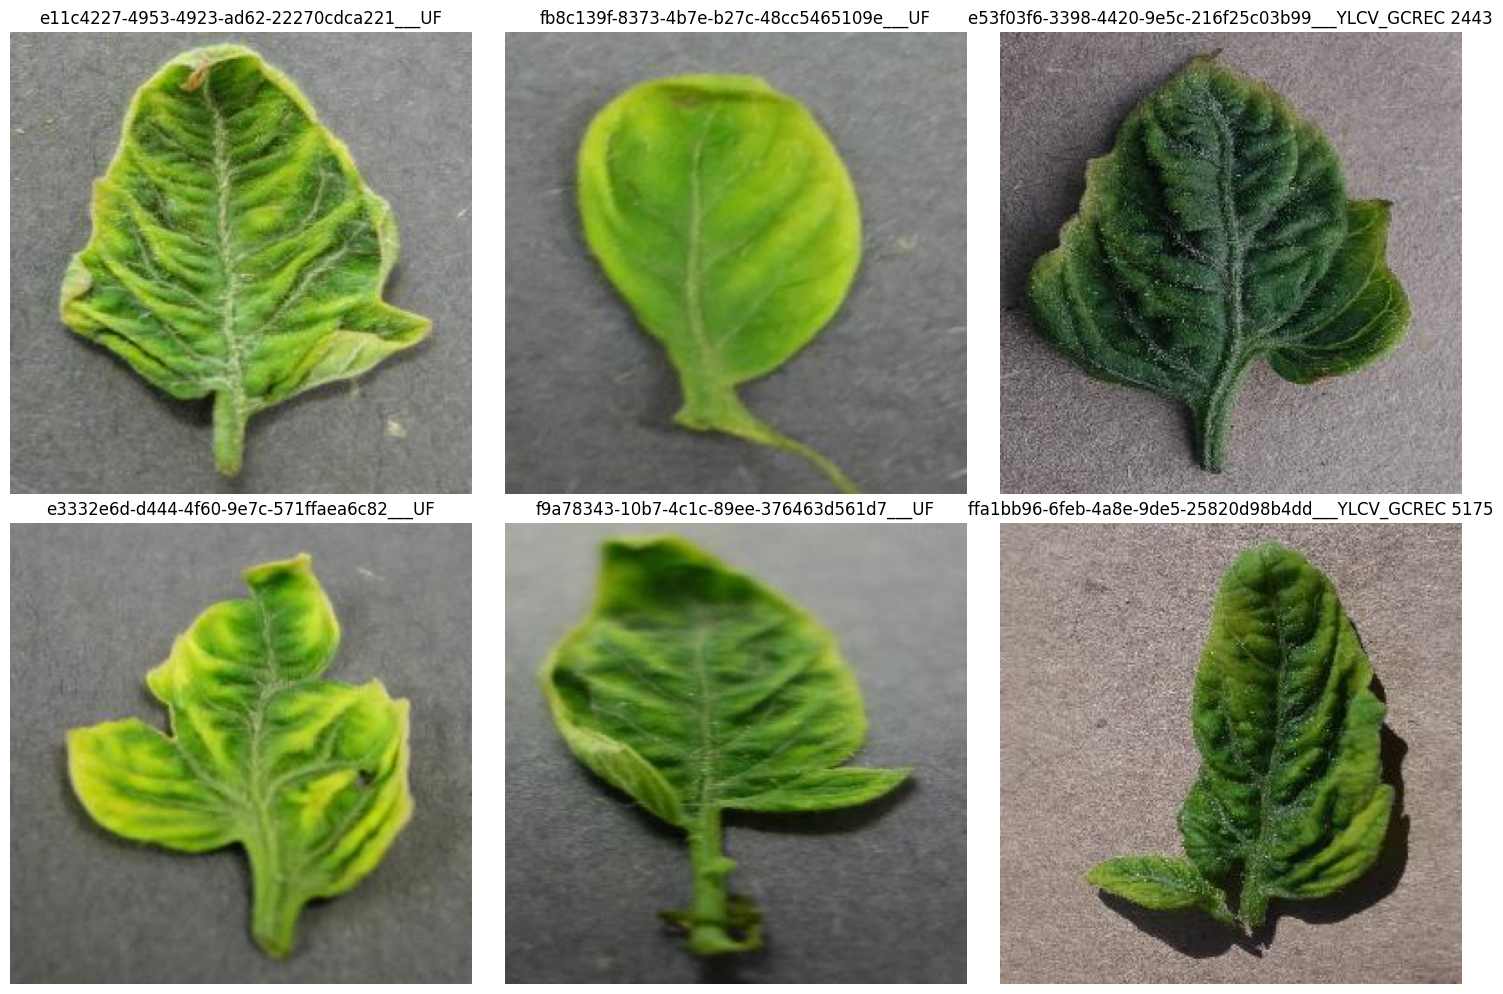

In [30]:
# Path to the directory containing images
path = "./tomatoleaf/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus"

# Get a list of all image file names in the directory
image_files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

# Display the first 6 images with their labels
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for i in range(6):
    # Get the image file name and its label
    image_file = image_files[i]
    label = image_file.split('.')[0]

    # Load and display the image
    img_path = os.path.join(path, image_file)
    img = mpimg.imread(img_path)
    ax = axs[i // 3, i % 3]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(label)

plt.tight_layout()
plt.show()

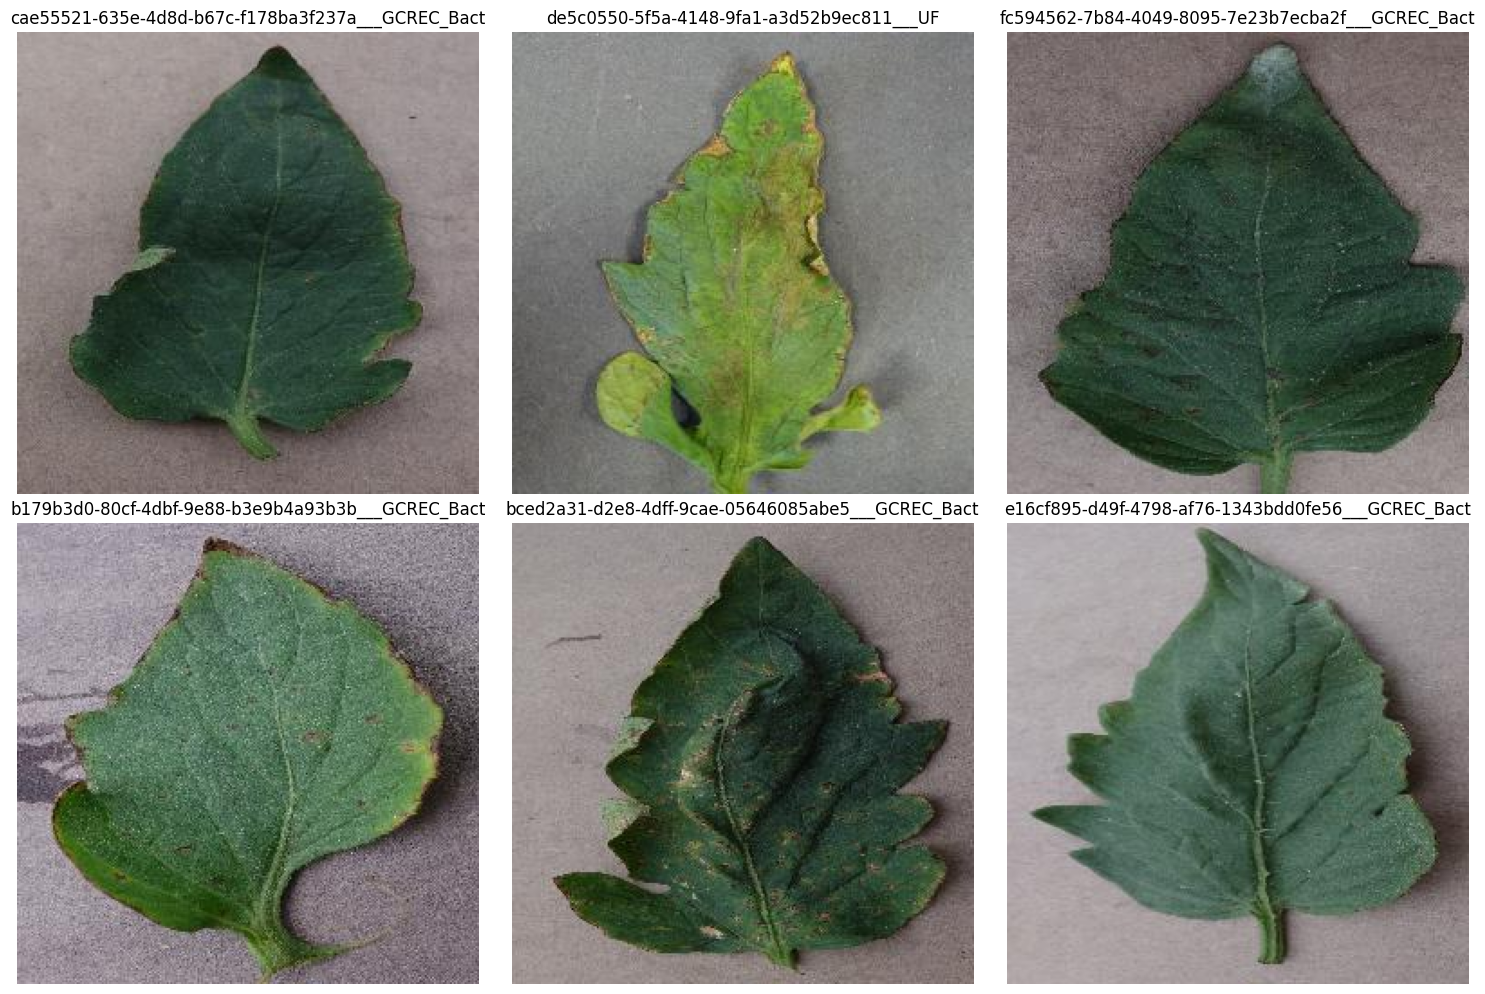

In [31]:
# Path to the directory containing images
path = "./tomatoleaf/tomato/train/Tomato___Bacterial_spot"

# Get a list of all image file names in the directory
image_files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

# Display the first 6 images with their labels
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for i in range(6):
    # Get the image file name and its label
    image_file = image_files[i]
    label = image_file.split('.')[0]

    # Load and display the image
    img_path = os.path.join(path, image_file)
    img = mpimg.imread(img_path)
    ax = axs[i // 3, i % 3]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(label)

plt.tight_layout()
plt.show()


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">4 | Training The Model</h1>
</div>

**WORKING**
- The code initializes a `DenseNet121` model with weights pre-trained on the ImageNet dataset.
- The `include_top=False argument` specifies that the model should not include the fully connected layers at the top of the network, which are typically used for ImageNet classification.
- The `input_shape=(256,256,3) argument` specifies the shape of the input images that the model expects, which is `256x256` pixels with 3 channels (RGB).
- The initialized model `conv_base` can be used as a feature extractor to extract features from images, which can then be used as input to a custom classification head.

In [32]:
conv_base = DenseNet121(
    weights='imagenet',
    include_top = False,
    input_shape=(256,256,3),
    pooling='avg'
)

**WHY FALSE ?**
- Setting conv_base.trainable = False freezes the weights of the pre-trained DenseNet121 model.
- This is done to prevent the weights from being updated during the training of the custom classification head.
- Freezing the pre-trained weights helps in utilizing the learned features from the ImageNet dataset without altering them.
- It also reduces the computational cost and training time, as only the weights of the custom classification head will be trained.

In [33]:
conv_base.trainable = False

In [34]:
# # Summary of the pretrained model
# conv_base.summary()

**WORKING**

- It initializes a Sequential model and adds the `pre-trained` DenseNet121` model (conv_base) ` as the base.
- The model flattens the output from the base model and adds two fully connected layers with `ReLU activation`.
- `Batch normalization` is applied after each fully connected layer to improve training stability and speed.

In [35]:
model = Sequential()
model.add(conv_base)
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.35))
model.add(BatchNormalization())
model.add(Dense(120, activation='relu'))
model.add(Dense(10, activation='softmax'))

**WORKING**

- The compile method is used to configure the model for training.
- The optimizer=Adam(lr=0.0001) argument specifies the Adam optimizer with a learning rate of 0.0001.
- The loss='categorical_crossentropy' argument specifies the loss function used for training, which is categorical crossentropy for multi-class classification.
- The metrics=['accuracy'] argument specifies the metric used to evaluate the model, which is accuracy in this case.

In [36]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

**WORKING**
- The `fit` method is used to train the model on the training data (`train_data`) for a specified number of epochs (100 in this case).
- The `validation_data=val_data` argument specifies the validation data to evaluate the model performance after each epoch.
- The `callbacks=[EarlyStopping(patience=0)]` argument specifies the use of early stopping to prevent overfitting. The training will stop if the validation loss does not improve after 0 epochs.
- The `history` variable stores the training history, including metrics such as loss and accuracy, which can be used for analysis and visualization.

In [37]:
# history = model.fit(train_ds,epochs=10,validation_data=validation_ds)
history = model.fit(train_data, epochs=100, validation_data=val_data, callbacks=[EarlyStopping(patience=0)])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.5153 - loss: 1.4556 - val_accuracy: 0.7360 - val_loss: 0.9307
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 154ms/step - accuracy: 0.5153 - loss: 1.4556 - val_accuracy: 0.7360 - val_loss: 0.9307
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.7683 - loss: 0.7284 - val_accuracy: 0.8450 - val_loss: 0.5113
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.7683 - loss: 0.7284 - val_accuracy: 0.8450 - val_loss: 0.5113
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8333 - loss: 0.5169 - val_accuracy: 0.8830 - val_loss: 0.3810
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8333 - loss: 0.5169 - val_accuracy: 0.8830 - val_loss: 0.3810
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8710 - loss: 0.3999 - val_accuracy: 0.8920 - val_loss: 0.3173
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8710 -

In [41]:
# Evaluate the model on the validation data
evaluation = model.evaluate(val_data)

# Print the evaluation metrics
print("Validation Loss:", evaluation[0])
print("Validation Accuracy:", evaluation[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.9550 - loss: 0.1485
Validation Loss: 0.14846791326999664
Validation Accuracy: 0.9549999833106995
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.9550 - loss: 0.1485
Validation Loss: 0.14846791326999664
Validation Accuracy: 0.9549999833106995


<div style="border-radius: 30px 0 30px 0px; border: 2px solid #00ea98; padding: 20px; background-color: #0a141b; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h1 style="color: #7ab052; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px;">5 | THE END </h1>
</div>

In [42]:
# Save the trained Keras model
model.save("trained_model.h5")
print("✅ Keras model saved as trained_model.h5")


✅ Keras model saved as trained_model.h5


In [43]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model("trained_model.h5")

# Create TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional) Enable optimizations for smaller model size
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save as .tflite
with open("trained_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted and saved as trained_model.tflite")


INFO:tensorflow:Assets written to: /tmp/tmpmbndz643/assets


INFO:tensorflow:Assets written to: /tmp/tmpmbndz643/assets


Saved artifact at '/tmp/tmpmbndz643'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140155809677392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798238416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798238608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798238032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798239376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798237648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798237456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798238992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798239568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798237072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140155798235

W0000 00:00:1762207485.171654 1506389 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1762207485.171676 1506389 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


✅ Model converted and saved as trained_model.tflite
